# Season simulator (prototype)

For each player we turn a single Sleeper season projection into a *distribution*:
classify the player into a tier (which sets his CV), then simulate many seasons of
17 availability-gated, gamma-distributed weeks and report floor / median / ceiling.

Inputs (already produced):
- `data/variance_params.parquet` -- position x tier -> cv, proj_floor, availability
- `data/projections_season.parquet` -- Sleeper season projections

Covers QB/RB/WR/TE (the positions we measured); K/DEF are skipped for now.
Uses PPR to match how we measured variance -- swap to `pts_half_ppr` if your league differs.

In [14]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

pl.Config.set_tbl_rows(100)

DATA = Path("data")   # launch Jupyter from the repo root
SEED = 42             # fixed so results are reproducible while we inspect
N_SIMS = 5000         # seasons simulated per player (lower to ~2000 to speed up)

params = pl.read_parquet(DATA / "variance_params.parquet")
proj = pl.read_parquet(DATA / "projections_season.parquet")

print("params rows:", params.height, "| projection rows:", proj.height)
params

params rows: 11 | projection rows: 637


position,tier,cv,proj_floor,availability
str,str,f64,f64,f64
"""QB""","""elite""",0.43098,271.92,0.931373
"""QB""","""starter""",0.557177,0.0,0.931373
"""RB""","""elite""",0.467638,242.8,0.914216
"""RB""","""starter""",0.641792,128.9,0.914216
"""RB""","""bench""",1.007675,0.0,0.914216
"""TE""","""elite""",0.572492,165.1,0.848039
"""TE""","""starter""",0.686956,78.7,0.848039
"""TE""","""bench""",0.986873,0.0,0.848039
"""WR""","""elite""",0.523233,219.9,0.879085


## Classify a player into his tier

Given a position and a season projection, pick the tier whose `proj_floor` is the
highest value still at or below the projection. That tier's CV and availability are
what we simulate with. (Reminder: `proj_floor` only *selects the tier* -- it never
bounds a simulated score.)

In [15]:
# Pre-index tiers per position, sorted by floor descending, for a fast lookup.
tiers_by_pos = {}
for pos in params["position"].unique().to_list():
    sub = params.filter(pl.col("position") == pos).sort("proj_floor", descending=True)
    tiers_by_pos[pos] = list(zip(sub["proj_floor"].to_list(),
                                 sub["cv"].to_list(),
                                 sub["availability"].to_list()))

def classify(position, projection):
    """Return (cv, availability) for a player, or None if position isn't covered."""
    for floor, cv, avail in tiers_by_pos.get(position, []):
        if projection >= floor:
            return cv, avail
    return None

# quick sanity check
for name, pos, pr in [("elite WR", "WR", 240), ("mid RB", "RB", 150), ("bench TE", "TE", 30)]:
    print(name, "->", classify(pos, pr))

elite WR -> (0.5232333209948624, 0.8790849673202614)
mid RB -> (0.6417917332357732, 0.9142156862745098)
bench TE -> (0.9868732153891266, 0.8480392156862745)


## The simulator

Per active week we draw from a **gamma** with mean `projection / (availability x 17)`
and `shape = 1 / cv^2`. Dividing by *expected* games (not 17) is what keeps the
projection as the season mean once availability zeroes out some weeks. Gamma's shape
does the rest: CV~1.0 bench players come out heavily right-skewed and floored at zero,
elite players near-symmetric.

In [16]:
def simulate_player(projection, cv, availability, n_sims=N_SIMS, n_weeks=17, rng=None):
    rng = rng if rng is not None else np.random.default_rng()
    mean_active = projection / (availability * n_weeks)   # preserves the season mean
    shape = 1.0 / (cv ** 2)
    scale = mean_active / shape                            # = mean_active * cv**2
    weekly = rng.gamma(shape, scale, size=(n_sims, n_weeks))   # points if active
    active = rng.random((n_sims, n_weeks)) < availability      # availability gate
    return (weekly * active).sum(axis=1)                       # season totals

# single-player smoke test
cv, avail = classify("RB", 240)
s = simulate_player(240, cv, avail, rng=np.random.default_rng(SEED))
print("proj 240 -> mean %.1f | p10 %.0f | p50 %.0f | p90 %.0f"
      % (s.mean(), *np.percentile(s, [10, 50, 90])))

proj 240 -> mean 239.6 | p10 186 | p50 238 | p90 295


## Run every player

Loop the projections, classify, simulate, and collect percentiles. ~10-20s for a
few hundred players at 5000 sims.

In [17]:
rng = np.random.default_rng(SEED)
usable = proj.filter(pl.col("position").is_in(["QB", "RB", "WR", "TE"]) & (pl.col("pts_ppr") > 0))

records = []
for r in usable.iter_rows(named=True):
    hit = classify(r["position"], r["pts_ppr"])
    if hit is None:
        continue
    cv, avail = hit
    season = simulate_player(r["pts_ppr"], cv, avail, rng=rng)
    p10, p50, p90 = np.percentile(season, [10, 50, 90])
    records.append({
        "name": r["name"], "position": r["position"], "team": r["team"],
        "projection": r["pts_ppr"],
        "floor_p10": round(float(p10), 1),
        "median_p50": round(float(p50), 1),
        "ceiling_p90": round(float(p90), 1),
        "sim_mean": round(float(season.mean()), 1),
        "cv": round(cv, 3),
    })

results = pl.DataFrame(records).sort("projection", descending=True)
print("players simulated:", results.height)
results.head(20)

players simulated: 559


name,position,team,projection,floor_p10,median_p50,ceiling_p90,sim_mean,cv
str,str,str,f64,f64,f64,f64,f64,f64
"""Josh Allen""","""QB""","""BUF""",361.5,302.2,360.5,421.6,361.3,0.431
"""Bijan Robinson""","""RB""","""ATL""",324.9,268.7,324.1,383.1,325.1,0.468
"""Drake Maye""","""QB""","""NEP""",320.76,268.7,319.4,374.1,320.4,0.431
"""Lamar Jackson""","""QB""","""BAL""",320.0,268.3,319.0,371.4,319.6,0.431
"""Jayden Daniels""","""QB""","""WAS""",313.72,264.0,313.7,363.0,314.0,0.431
"""Puka Nacua""","""WR""","""LAR""",312.5,249.6,310.9,377.9,312.5,0.523
"""Ja'Marr Chase""","""WR""","""CIN""",311.1,248.6,309.4,377.9,312.0,0.523
"""Jalen Hurts""","""QB""","""PHI""",310.54,261.0,310.3,362.5,311.0,0.431
"""Jahmyr Gibbs""","""RB""","""DET""",307.9,253.0,307.3,364.9,308.4,0.468


## Validation: did the projection stay the mean?

`sim_mean` should track `projection` closely (a few points of sampling noise). Note
`median_p50` sits a touch *below* the mean for skewed players -- that's correct, not
a bug: right-skew pulls the mean above the median, and it's most visible on high-CV
bench guys.

In [18]:
check = results.with_columns((pl.col("sim_mean") - pl.col("projection")).abs().alias("abs_diff"))
print("max |sim_mean - projection|:", round(check["abs_diff"].max(), 2))
print("mean |sim_mean - projection|:", round(check["abs_diff"].mean(), 2))
check.select(["name", "position", "projection", "sim_mean", "median_p50", "ceiling_p90"]).head(10)

max |sim_mean - projection|: 1.42
mean |sim_mean - projection|: 0.18


name,position,projection,sim_mean,median_p50,ceiling_p90
str,str,f64,f64,f64,f64
"""Josh Allen""","""QB""",361.5,361.3,360.5,421.6
"""Bijan Robinson""","""RB""",324.9,325.1,324.1,383.1
"""Drake Maye""","""QB""",320.76,320.4,319.4,374.1
"""Lamar Jackson""","""QB""",320.0,319.6,319.0,371.4
"""Jayden Daniels""","""QB""",313.72,314.0,313.7,363.0
"""Puka Nacua""","""WR""",312.5,312.5,310.9,377.9
"""Ja'Marr Chase""","""WR""",311.1,312.0,309.4,377.9
"""Jalen Hurts""","""QB""",310.54,311.0,310.3,362.5
"""Jahmyr Gibbs""","""RB""",307.9,308.4,307.3,364.9


## Inspect one player's distribution

Change `PLAYER` to any name in the projections. The spread between the dashed floor
and ceiling is the whole point -- it's what a single Sleeper number can't tell you.

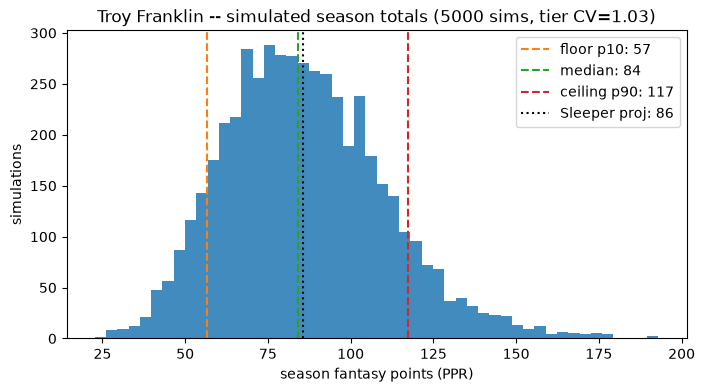

In [19]:
PLAYER = "Troy Franklin"   # <-- change to inspect anyone

r = usable.filter(pl.col("name") == PLAYER).row(0, named=True)
cv, avail = classify(r["position"], r["pts_ppr"])
season = simulate_player(r["pts_ppr"], cv, avail, rng=np.random.default_rng(SEED))
p10, p50, p90 = np.percentile(season, [10, 50, 90])

plt.figure(figsize=(8, 4))
plt.hist(season, bins=50, alpha=0.85)
for v, lbl, c in [(p10, "floor p10", "C1"), (p50, "median", "C2"), (p90, "ceiling p90", "C3")]:
    plt.axvline(v, color=c, linestyle="--", label=f"{lbl}: {v:.0f}")
plt.axvline(r["pts_ppr"], color="k", linestyle=":", label=f"Sleeper proj: {r['pts_ppr']:.0f}")
plt.title(f"{PLAYER} -- simulated season totals ({N_SIMS} sims, tier CV={cv:.2f})")
plt.xlabel("season fantasy points (PPR)"); plt.ylabel("simulations")
plt.legend(); plt.show()

If this all looks right -- means tracking projections, floors/ceilings sensible,
bench players visibly wider than elites -- we're ready to lift this into a repo script
(`scripts/simulate_projections.py`) that writes a `projections_sim.parquet` for the
dashboard's model column, and wire it into the daily job.